<a href="https://colab.research.google.com/github/nehalahane22-sketch/DeepCSAT-E-Commerce-Customer-Satisfaction-Score-Prediction/blob/main/DeepLearnCSAT_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# DEPENDENCIES & DATA UPLOAD
# ============================================================

!pip install -q tensorflow scikit-learn pandas numpy nltk shap pyngrok

In [2]:


import pandas as pd
import numpy as np
import io
import os

from google.colab import files

print("Please upload your Shopzilla dataset CSV file:")

uploaded = files.upload()

# Check whether a file was uploaded
if not uploaded:
    raise ValueError("No file was uploaded. Please upload a CSV dataset.")

# Get uploaded filename
file_name = list(uploaded.keys())[0]

# Check file extension
if not file_name.lower().endswith(".csv"):
    raise ValueError(
        f"'{file_name}' is not a CSV file. Please upload a CSV dataset."
    )

# Read CSV
try:
    df = pd.read_csv(io.BytesIO(uploaded[file_name]))
except UnicodeDecodeError:
    # Fallback for CSV files with non-UTF-8 encoding
    df = pd.read_csv(
        io.BytesIO(uploaded[file_name]),
        encoding="latin-1"
    )

print("\n" + "=" * 60)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)

print(f"File name : {file_name}")
print(f"Rows      : {df.shape[0]:,}")
print(f"Columns   : {df.shape[1]:,}")

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())


Please upload your Shopzilla dataset CSV file:


Saving eCommerce_Customer_support_data.csv to eCommerce_Customer_support_data.csv

DATASET LOADED SUCCESSFULLY
File name : eCommerce_Customer_support_data.csv
Rows      : 85,907
Columns   : 20

First 5 rows:


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5



Column names:
['Unique id', 'channel_name', 'category', 'Sub-category', 'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at', 'issue_responded', 'Survey_response_Date', 'Customer_City', 'Product_category', 'Item_price', 'connected_handling_time', 'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score']


In [3]:
# ============================================================
# CELL 2A: CHECK NULL VALUES BEFORE CLEANING
# ============================================================

print("=" * 60)
print("NULL VALUE ANALYSIS - BEFORE CLEANING")
print("=" * 60)

# Count null values
null_counts = df.isnull().sum()

# Calculate percentage of null values
null_percentage = (df.isnull().sum() / len(df)) * 100

# Create summary table
null_summary = pd.DataFrame({
    'Null Count': null_counts,
    'Null Percentage': null_percentage
})

# Show only columns containing null values
null_summary = null_summary[null_summary['Null Count'] > 0]

# Sort by highest number of missing values
null_summary = null_summary.sort_values(
    by='Null Count',
    ascending=False
)

if null_summary.empty:
    print("✅ No missing values found in the dataset.")
else:
    display(null_summary)

print(f"\nTotal rows: {len(df):,}")
print(f"Total columns: {len(df.columns):,}")
print(f"Total missing values: {df.isnull().sum().sum():,}")


NULL VALUE ANALYSIS - BEFORE CLEANING


,Null Count,Null Percentage
connected_handling_time,85665,99.718300
Customer_City,68828,80.119199
Product_category,68711,79.983005
Item_price,68701,79.971364
order_date_time,68693,79.962052
Customer Remarks,57165,66.542889
Order_id,18232,21.222950



Total rows: 85,907
Total columns: 20
Total missing values: 435,995


In [31]:
# ============================================================
# CELL 2B: CLEANING AND HANDLING MISSING VALUES
# ============================================================

df = df.copy()

# ------------------------------------------------------------
# 1. Remove duplicate records
# ------------------------------------------------------------

if 'Unique id' in df.columns:
    before = len(df)

    df = df.drop_duplicates(subset=['Unique id'])

    print(f"Duplicate records removed: {before - len(df):,}")


# ------------------------------------------------------------
# 2. Drop columns with extremely high missingness
# ------------------------------------------------------------

drop_cols = [
    'connected_handling_time'
]

# Only drop columns that actually exist
drop_cols = [col for col in drop_cols if col in df.columns]

df = df.drop(columns=drop_cols)

print(f"\nDropped highly incomplete columns: {drop_cols}")


# ------------------------------------------------------------
# 3. Handle categorical/text columns
# ------------------------------------------------------------

categorical_cols = [
    'Customer_City',
    'Product_category',
    'Customer Remarks'
]

for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown').astype(str)


# ------------------------------------------------------------
# 4. Handle numerical columns
# ------------------------------------------------------------

numeric_cols = [
    'Item_price'
]

for col in numeric_cols:
    if col in df.columns:

        # Convert to numeric if necessary
        df[col] = pd.to_numeric(df[col], errors='coerce')

        # Replace negative values with NaN
        df.loc[df[col] < 0, col] = np.nan

        # Median imputation
        if df[col].notna().any():
            df[col] = df[col].fillna(df[col].median())


# ------------------------------------------------------------
# 5. Remove rows where target CSAT Score is missing
# ------------------------------------------------------------

if 'CSAT Score' in df.columns:
    before = len(df)

    df = df.dropna(subset=['CSAT Score'])

    print(f"Rows removed due to missing CSAT Score: {before - len(df):,}")
else:
    raise ValueError("CSAT Score column was not found in the dataset.")


# ------------------------------------------------------------
# 6. Final dataset information
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CLEANING COMPLETED")
print("=" * 60)

print(f"Final dataset shape: {df.shape}")
print(f"Final number of records: {len(df):,}")

Duplicate records removed: 0

Dropped highly incomplete columns: []
Rows removed due to missing CSAT Score: 0

CLEANING COMPLETED
Final dataset shape: (85907, 28)
Final number of records: 85,907


In [19]:
df.describe(include='all')
df.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'Agent_name', 'Supervisor', 'Manager',
       'Tenure Bucket', 'Agent Shift', 'CSAT Score', 'sentiment_compound',
       'sentiment_neg', 'sentiment_pos', 'remark_length'],
      dtype='object')

In [21]:
# ============================================================
# CELL 3: FEATURE ENGINEERING & SENTIMENT ANALYSIS
# ============================================================
#
# PURPOSE:
# Transform raw date/time and customer-feedback information
# into meaningful numerical features for DeepCSAT.
#
# FEATURES CREATED:
#
# 1. response_time_min
#       Time taken by the agent to respond to the issue.
#
# 2. order_to_issue_delay_hrs
#       Time between order placement and issue reporting.
#
# 3. issue_hour
#       Hour at which the customer reported the issue.
#
# 4. issue_dayofweek
#       Day of week when the issue was reported.
#
# 5. is_weekend
#       1 = Saturday/Sunday
#       0 = Weekday
#
# 6. sentiment_compound
#       Overall customer sentiment score.
#
# 7. sentiment_neg
#       Negative sentiment score.
#
# 8. sentiment_pos
#       Positive sentiment score.
#
# 9. remark_length
#       Number of characters in the customer's remark.
#
# ============================================================


# ============================================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import nltk

from nltk.sentiment.vader import SentimentIntensityAnalyzer


# Download VADER sentiment dictionary.
# quiet=True prevents unnecessary download messages.
nltk.download('vader_lexicon', quiet=True)

# Create VADER sentiment analyzer.
sia = SentimentIntensityAnalyzer()


# ============================================================
# 2. VERIFY SOURCE COLUMNS
# ============================================================
#
# These are the EXACT column names from your dataset.
#
# IMPORTANT:
# 'Issue_reported at' contains a SPACE before "at".
#
# ============================================================

required_columns = [
    'order_date_time',
    'Issue_reported at',
    'issue_responded',
    'Survey_response_Date',
    'Customer Remarks'
]

print("=" * 65)
print("SOURCE COLUMN VALIDATION")
print("=" * 65)

for col in required_columns:

    if col in df.columns:
        print(f"✅ {col}")
    else:
        print(f"❌ {col} NOT FOUND")


# ============================================================
# 3. CONVERT DATE/TIME COLUMNS
# ============================================================
#
# Date/time columns must be converted to pandas datetime
# format before we perform time calculations.
#
# errors='coerce':
# Invalid date values become NaT instead of causing an error.
#
# ============================================================

datetime_cols = [
    'order_date_time',
    'Issue_reported at',
    'issue_responded',
    'Survey_response_Date'
]

for col in datetime_cols:

    if col in df.columns:

        df[col] = pd.to_datetime(
            df[col],
            errors='coerce'
        )

print("\n✅ Date/time conversion completed.")


# ============================================================
# 4. PREPARE CUSTOMER REMARKS
# ============================================================
#
# Customer Remarks contains text.
#
# Missing remarks are replaced with an empty string.
# This prevents errors during sentiment analysis and
# remark-length calculation.
#
# ============================================================

if 'Customer Remarks' in df.columns:

    df['Customer Remarks'] = (
        df['Customer Remarks']
        .fillna('')
        .astype(str)
    )

    print("✅ Customer Remarks prepared.")

else:

    raise ValueError(
        "❌ 'Customer Remarks' column not found."
    )


# ============================================================
# 5. RESPONSE TIME
# ============================================================
#
# BUSINESS QUESTION:
#
# How long did the customer wait for a response?
#
# Formula:
#
#     issue_responded - Issue_reported at
#
# Result:
#
#     response_time_min
#
# Example:
#
#     Issue reported  = 10:00
#     Issue responded = 10:30
#
#     Response time = 30 minutes
#
# WHY?
#
# Response speed is an important customer-service factor and
# may have a relationship with CSAT.
#
# ============================================================

if (
    'Issue_reported at' in df.columns
    and 'issue_responded' in df.columns
):

    df['response_time_min'] = (
        df['issue_responded']
        - df['Issue_reported at']
    ).dt.total_seconds() / 60

    # Negative response times are logically invalid.
    # Convert them to missing values.
    df.loc[
        df['response_time_min'] < 0,
        'response_time_min'
    ] = np.nan

    # Replace missing values with median response time.
    if df['response_time_min'].notna().any():

        median_response = (
            df['response_time_min'].median()
        )

        df['response_time_min'] = (
            df['response_time_min']
            .fillna(median_response)
        )

    else:

        df['response_time_min'] = 0.0

    print("✅ response_time_min created.")


# ============================================================
# 6. ORDER-TO-ISSUE DELAY
# ============================================================
#
# BUSINESS QUESTION:
#
# How much time passed between placing the order and
# reporting the issue?
#
# Formula:
#
#     Issue_reported at - order_date_time
#
# Result:
#
#     order_to_issue_delay_hrs
#
# WHY?
#
# The timing of a complaint may provide information about
# the customer's experience.
#
# ============================================================

if (
    'order_date_time' in df.columns
    and 'Issue_reported at' in df.columns
):

    df['order_to_issue_delay_hrs'] = (
        df['Issue_reported at']
        - df['order_date_time']
    ).dt.total_seconds() / 3600

    # Negative values are logically invalid.
    df.loc[
        df['order_to_issue_delay_hrs'] < 0,
        'order_to_issue_delay_hrs'
    ] = np.nan

    # Replace missing values with median.
    if df['order_to_issue_delay_hrs'].notna().any():

        median_delay = (
            df['order_to_issue_delay_hrs'].median()
        )

        df['order_to_issue_delay_hrs'] = (
            df['order_to_issue_delay_hrs']
            .fillna(median_delay)
        )

    else:

        df['order_to_issue_delay_hrs'] = 0.0

    print("✅ order_to_issue_delay_hrs created.")


# ============================================================
# 7. ISSUE TIME FEATURES
# ============================================================
#
# Extract useful information from the time when the customer
# reported the issue.
#
# issue_hour:
#     0 - 23
#
# issue_dayofweek:
#     Monday    = 0
#     Tuesday   = 1
#     Wednesday = 2
#     Thursday  = 3
#     Friday    = 4
#     Saturday  = 5
#     Sunday    = 6
#
# is_weekend:
#     1 = Saturday or Sunday
#     0 = Weekday
#
# WHY?
#
# Customer-service workload and response patterns can differ
# by hour and day.
#
# ============================================================

if 'Issue_reported at' in df.columns:

    # Extract hour of the day.
    df['issue_hour'] = (
        df['Issue_reported at']
        .dt.hour
    )

    # Extract day of week.
    df['issue_dayofweek'] = (
        df['Issue_reported at']
        .dt.dayofweek
    )

    # Handle missing values.
    df['issue_hour'] = (
        df['issue_hour']
        .fillna(12)
        .astype(int)
    )

    df['issue_dayofweek'] = (
        df['issue_dayofweek']
        .fillna(0)
        .astype(int)
    )

    # Weekend indicator.
    df['is_weekend'] = (
        df['issue_dayofweek']
        .isin([5, 6])
        .astype(int)
    )

    print("✅ issue_hour created.")
    print("✅ issue_dayofweek created.")
    print("✅ is_weekend created.")


# ============================================================
# 8. VADER SENTIMENT ANALYSIS
# ============================================================
#
# Customer Remarks contains natural-language feedback.
#
# VADER converts the text into numerical sentiment scores.
#
# sentiment_compound:
#     Overall sentiment.
#     -1 = very negative
#      0 = neutral
#     +1 = very positive
#
# sentiment_neg:
#     Strength of negative sentiment.
#
# sentiment_pos:
#     Strength of positive sentiment.
#
# WHY?
#
# Customer emotions expressed in remarks can provide useful
# information for predicting CSAT.
#
# ============================================================

df['sentiment_compound'] = (
    df['Customer Remarks']
    .apply(
        lambda text:
        sia.polarity_scores(text)['compound']
    )
)

df['sentiment_neg'] = (
    df['Customer Remarks']
    .apply(
        lambda text:
        sia.polarity_scores(text)['neg']
    )
)

df['sentiment_pos'] = (
    df['Customer Remarks']
    .apply(
        lambda text:
        sia.polarity_scores(text)['pos']
    )
)

print("✅ sentiment_compound created.")
print("✅ sentiment_neg created.")
print("✅ sentiment_pos created.")


# ============================================================
# 9. CUSTOMER REMARK LENGTH
# ============================================================
#
# Count the number of characters in each customer remark.
#
# WHY?
#
# Longer remarks may contain more detailed complaints,
# explanations, or feedback.
#
# ============================================================

df['remark_length'] = (
    df['Customer Remarks']
    .apply(len)
)

print("✅ remark_length created.")


# ============================================================
# 10. FINAL FEATURE LIST
# ============================================================

engineered_features = [
    'response_time_min',
    'order_to_issue_delay_hrs',
    'issue_hour',
    'issue_dayofweek',
    'is_weekend',
    'sentiment_compound',
    'sentiment_neg',
    'sentiment_pos',
    'remark_length'
]


# ============================================================
# 11. VALIDATE ENGINEERED FEATURES
# ============================================================

print("\n" + "=" * 65)
print("ENGINEERED FEATURE VALIDATION")
print("=" * 65)

for col in engineered_features:

    if col in df.columns:
        print(f"✅ {col}")
    else:
        print(f"❌ {col} NOT FOUND")


# ============================================================
# 12. CHECK NULL VALUES IN ENGINEERED FEATURES
# ============================================================

print("\n" + "=" * 65)
print("NULL VALUE CHECK - ENGINEERED FEATURES")
print("=" * 65)

print(
    df[engineered_features]
    .isnull()
    .sum()
)


# ============================================================
# 13. DISPLAY SAMPLE
# ============================================================
#
# This lets us manually verify that the new features contain
# reasonable values.
#
# ============================================================

print("\n" + "=" * 65)
print("SAMPLE OF ENGINEERED FEATURES")
print("=" * 65)

display(
    df[engineered_features].head(10)
)


# ============================================================
# 14. FINAL DATASET INFORMATION
# ============================================================

print("\n" + "=" * 65)
print("CELL 3 COMPLETED")
print("=" * 65)

print(f"Total records : {len(df):,}")
print(f"Total columns : {len(df.columns)}")

print("\nNew features added:")
for col in engineered_features:
    print(f"  • {col}")

print("\n✅ Feature engineering and sentiment analysis completed.")
print("✅ Data is ready for Cell 4 preprocessing.")

SOURCE COLUMN VALIDATION
✅ order_date_time
✅ Issue_reported at
✅ issue_responded
✅ Survey_response_Date
✅ Customer Remarks

✅ Date/time conversion completed.
✅ Customer Remarks prepared.
✅ response_time_min created.
✅ order_to_issue_delay_hrs created.
✅ issue_hour created.
✅ issue_dayofweek created.
✅ is_weekend created.
✅ sentiment_compound created.
✅ sentiment_neg created.
✅ sentiment_pos created.
✅ remark_length created.

ENGINEERED FEATURE VALIDATION
✅ response_time_min
✅ order_to_issue_delay_hrs
✅ issue_hour
✅ issue_dayofweek
✅ is_weekend
✅ sentiment_compound
✅ sentiment_neg
✅ sentiment_pos
✅ remark_length

NULL VALUE CHECK - ENGINEERED FEATURES
response_time_min           0
order_to_issue_delay_hrs    0
issue_hour                  0
issue_dayofweek             0
is_weekend                  0
sentiment_compound          0
sentiment_neg               0
sentiment_pos               0
remark_length               0
dtype: int64

SAMPLE OF ENGINEERED FEATURES


,response_time_min,order_to_issue_delay_hrs,issue_hour,issue_dayofweek,is_weekend,sentiment_compound,sentiment_neg,sentiment_pos,remark_length
0,34.0,2266.566667,11,6,1,0.0000,0.0,0.000,7
1,2.0,2266.566667,12,6,1,0.0000,0.0,0.000,7
2,22.0,2266.566667,20,6,1,0.0000,0.0,0.000,7
3,20.0,2266.566667,20,6,1,0.0000,0.0,0.000,7
4,2.0,2266.566667,10,6,1,0.0000,0.0,0.000,7
5,206.0,2266.566667,15,6,1,0.0000,0.0,0.000,7
6,501.0,2266.566667,15,6,1,0.0000,0.0,0.000,7
7,6.0,2266.566667,16,6,1,0.4927,0.0,0.762,9
8,4.0,2266.566667,21,6,1,0.7501,0.0,0.330,89
9,5.0,2266.566667,23,6,1,0.0000,0.0,0.000,7



CELL 3 COMPLETED
Total records : 85,907
Total columns : 28

New features added:
  • response_time_min
  • order_to_issue_delay_hrs
  • issue_hour
  • issue_dayofweek
  • is_weekend
  • sentiment_compound
  • sentiment_neg
  • sentiment_pos
  • remark_length

✅ Feature engineering and sentiment analysis completed.
✅ Data is ready for Cell 4 preprocessing.


In [22]:
df.columns
df.dtypes

,0
Unique id,object
channel_name,object
category,object
Sub-category,object
Customer Remarks,object
Order_id,object
order_date_time,datetime64[ns]
Issue_reported at,datetime64[ns]
issue_responded,datetime64[ns]
Survey_response_Date,datetime64[ns]


In [23]:
# ============================================================
# CELL 4: DATA PREPROCESSING & INPUT MATRIX PREPARATION
# ============================================================
#
# PURPOSE:
# Prepare the cleaned dataset for DeepCSAT model training.
#
# IMPORTANT:
# We split the data BEFORE fitting StandardScaler and
# OneHotEncoder to avoid data leakage.
#
# ============================================================


# ------------------------------------------------------------
# 1. IMPORT REQUIRED LIBRARIES
# ------------------------------------------------------------

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

import numpy as np
import pandas as pd


# ============================================================
# 2. DEFINE CATEGORICAL FEATURES
# ============================================================
#
# These columns contain categories/text rather than continuous
# numerical values.
#
# OneHotEncoder will convert these categories into numerical
# binary columns that the neural network can understand.
#
# ============================================================

categorical_cols = [
    'channel_name',
    'category',
    'Sub-category',
    'Customer_City',
    'Product_category',
    'Tenure Bucket',
    'Agent Shift'
]


# ============================================================
# 3. DEFINE NUMERICAL FEATURES
# ============================================================
#
# These are numerical features that can be directly used after
# standardization.
#
# Item_price:
#   Original numerical feature.
#
# response_time_min:
#   How many minutes the customer waited for a response.
#
# order_to_issue_delay_hrs:
#   Time between order placement and issue reporting.
#
# issue_hour:
#   Hour when the customer reported the issue.
#
# issue_dayofweek:
#   Day of the week when the issue was reported.
#
# is_weekend:
#   1 = Weekend
#   0 = Weekday
#
# remark_length:
#   Number of characters in the customer remark.
#
# Sentiment features:
#   Numerical representation of customer feedback sentiment.
#
# ============================================================

numerical_cols = [
    'Item_price',
    'response_time_min',
    'order_to_issue_delay_hrs',
    'issue_hour',
    'issue_dayofweek',
    'is_weekend',
    'remark_length',
    'sentiment_compound',
    'sentiment_neg',
    'sentiment_pos'
]


# ============================================================
# 4. CHECK ACTUAL COLUMNS IN THE DATASET
# ============================================================
#
# This is important because column names must match EXACTLY.
#
# We separate available and missing columns so that we can
# clearly see what will be used by the model.
#
# ============================================================

cat_present = [
    col for col in categorical_cols
    if col in df.columns
]

num_present = [
    col for col in numerical_cols
    if col in df.columns
]

cat_missing = [
    col for col in categorical_cols
    if col not in df.columns
]

num_missing = [
    col for col in numerical_cols
    if col not in df.columns
]


print("=" * 60)
print("FEATURE COLUMN VALIDATION")
print("=" * 60)

print("\nCategorical features being used:")
print(cat_present)

print("\nNumerical features being used:")
print(num_present)


if cat_missing:
    print("\n⚠️ Categorical columns not found:")
    print(cat_missing)

if num_missing:
    print("\n⚠️ Numerical columns not found:")
    print(num_missing)


# ============================================================
# 5. CHECK TARGET VARIABLE
# ============================================================
#
# CSAT Score is the value that our DeepCSAT model will predict.
#
# X = input features
# y = target CSAT Score
#
# ============================================================

if 'CSAT Score' not in df.columns:
    raise ValueError(
        "❌ 'CSAT Score' column was not found in the dataset."
    )


# ============================================================
# 6. CREATE X AND y
# ============================================================

feature_cols = num_present + cat_present

X = df[feature_cols].copy()
y = df['CSAT Score'].copy()


print("\n" + "=" * 60)
print("INPUT / TARGET DATA")
print("=" * 60)

print(f"Number of input features : {len(feature_cols)}")
print(f"Number of records        : {len(X):,}")
print(f"Target variable          : CSAT Score")


# ============================================================
# 7. CHECK TARGET DISTRIBUTION
# ============================================================
#
# We use stratify=y later so that the distribution of CSAT
# scores remains approximately similar in train and test sets.
#
# ============================================================

print("\nCSAT Score distribution:")
print(y.value_counts().sort_index())


# ============================================================
# 8. TRAIN / TEST SPLIT
# ============================================================
#
# IMPORTANT:
# We split the raw data BEFORE fitting the preprocessor.
#
# 80% -> Training data
# 20% -> Testing data
#
# random_state=42:
#   Makes the split reproducible.
#
# stratify=y:
#   Keeps a similar CSAT score distribution in both datasets.
#
# ============================================================

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\n" + "=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print(f"Training records : {len(X_train_raw):,}")
print(f"Testing records  : {len(X_test_raw):,}")


# ============================================================
# 9. CREATE PREPROCESSING PIPELINE
# ============================================================
#
# Numerical features:
#   StandardScaler
#
# This converts numerical variables to a similar scale.
#
# Categorical features:
#   OneHotEncoder
#
# This converts categories into numerical binary features.
#
# handle_unknown='ignore':
#   Prevents errors if a category appears in the test set that
#   was not present in the training set.
#
# ============================================================

transformers = []

if num_present:
    transformers.append(
        (
            'num',
            StandardScaler(),
            num_present
        )
    )

if cat_present:
    transformers.append(
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            cat_present
        )
    )


preprocessor = ColumnTransformer(
    transformers=transformers
)


# ============================================================
# 10. FIT PREPROCESSOR ONLY ON TRAINING DATA
# ============================================================
#
# THIS IS THE IMPORTANT DATA-LEAKAGE FIX.
#
# The scaler and encoder learn their parameters ONLY from the
# training dataset.
#
# The test dataset remains completely unseen during fitting.
#
# ============================================================

X_train = preprocessor.fit_transform(X_train_raw)

# Apply the already-fitted preprocessing to test data.
X_test = preprocessor.transform(X_test_raw)


# ============================================================
# 11. CONVERT TARGETS TO NUMPY ARRAYS
# ============================================================

y_train = np.asarray(y_train)
y_test = np.asarray(y_test)


# ============================================================
# 12. DISPLAY FINAL MATRIX SHAPES
# ============================================================

print("\n" + "=" * 60)
print("PREPROCESSING COMPLETED")
print("=" * 60)

print(f"Training feature matrix : {X_train.shape}")
print(f"Testing feature matrix  : {X_test.shape}")

print(f"Training target shape   : {y_train.shape}")
print(f"Testing target shape    : {y_test.shape}")


# ============================================================
# 13. FINAL VALIDATION
# ============================================================

print("\n" + "=" * 60)
print("FINAL VALIDATION")
print("=" * 60)

print(f"Training samples : {X_train.shape[0]:,}")
print(f"Testing samples  : {X_test.shape[0]:,}")
print(f"Input dimensions : {X_train.shape[1]:,}")

print("\n✅ Data preprocessing completed successfully.")
print("✅ No preprocessing leakage from test data.")
print("✅ Data is ready for DeepCSAT model training.")

FEATURE COLUMN VALIDATION

Categorical features being used:
['channel_name', 'category', 'Sub-category', 'Customer_City', 'Product_category', 'Tenure Bucket', 'Agent Shift']

Numerical features being used:
['Item_price', 'response_time_min', 'order_to_issue_delay_hrs', 'issue_hour', 'issue_dayofweek', 'is_weekend', 'remark_length', 'sentiment_compound', 'sentiment_neg', 'sentiment_pos']

INPUT / TARGET DATA
Number of input features : 17
Number of records        : 85,907
Target variable          : CSAT Score

CSAT Score distribution:
CSAT Score
1    11230
2     1283
3     2558
4    11219
5    59617
Name: count, dtype: int64

TRAIN / TEST SPLIT
Training records : 68,725
Testing records  : 17,182

PREPROCESSING COMPLETED
Training feature matrix : (68725, 1724)
Testing feature matrix  : (17182, 1724)
Training target shape   : (68725,)
Testing target shape    : (17182,)

FINAL VALIDATION
Training samples : 68,725
Testing samples  : 17,182
Input dimensions : 1,724

✅ Data preprocessing compl

In [24]:
# ============================================================
# CELL 5: DEEPCSAT NEURAL NETWORK ARCHITECTURE & TRAINING
# ============================================================
#
# PURPOSE:
# Build and train a Deep Learning model to predict CSAT Score.
#
# TARGET:
#     CSAT Score = 1, 2, 3, 4, or 5
#
# PROBLEM TYPE:
#     Regression
#
# The model predicts a continuous value such as:
#
#     4.72
#
# which can later be rounded/clipped to the CSAT scale:
#
#     1 - 5
#
# ============================================================


# ============================================================
# 1. IMPORT TENSORFLOW
# ============================================================

import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import callbacks


# Set a random seed so that model initialization and training
# are more reproducible.
tf.random.set_seed(42)


# ============================================================
# 2. BUILD DEEPCSAT MODEL
# ============================================================
#
# Architecture:
#
# Input
#   ↓
# Feature Attention Gate
#   ↓
# Dense Layer 128
#   ↓
# Batch Normalization
#   ↓
# Dropout
#   ↓
# Dense Layer 128
#   ↓
# Batch Normalization
#   ↓
# Dropout
#   ↓
# Residual / Skip Connection
#   ↓
# Dense Layer 64
#   ↓
# Batch Normalization
#   ↓
# Linear Output
#
# ============================================================


def build_csat_ann(input_dim):

    # --------------------------------------------------------
    # INPUT LAYER
    # --------------------------------------------------------
    #
    # input_dim = number of processed features.
    #
    # Your current preprocessing produces:
    #
    #     1,724 features
    #
    # --------------------------------------------------------

    inputs = layers.Input(
        shape=(input_dim,),
        name="CSAT_Input"
    )


    # --------------------------------------------------------
    # FEATURE ATTENTION GATE
    # --------------------------------------------------------
    #
    # The attention gate learns a weight between 0 and 1
    # for each input feature.
    #
    # sigmoid produces values between:
    #
    #     0 → feature receives little importance
    #     1 → feature receives high importance
    #
    # The model then multiplies the original input by these
    # learned weights.
    #
    # This allows the network to learn which processed
    # features are more useful for CSAT prediction.
    #
    # --------------------------------------------------------

    attention_weights = layers.Dense(
        input_dim,
        activation='sigmoid',
        name="Feature_Attention"
    )(inputs)

    gated_inputs = layers.Multiply(
        name="Attention_Gating"
    )([
        inputs,
        attention_weights
    ])


    # --------------------------------------------------------
    # DENSE BLOCK 1
    # --------------------------------------------------------
    #
    # 128 neurons learn nonlinear relationships between
    # customer, operational and sentiment features.
    #
    # Swish is used as the activation function because it
    # provides smooth nonlinear transformations.
    #
    # BatchNormalization helps stabilize training.
    #
    # Dropout reduces overfitting.
    #
    # --------------------------------------------------------

    x1 = layers.Dense(
        128,
        activation='swish',
        name="Dense_128_A"
    )(gated_inputs)

    x1 = layers.BatchNormalization(
        name="BatchNorm_A"
    )(x1)

    x1 = layers.Dropout(
        0.30,
        name="Dropout_A"
    )(x1)


    # --------------------------------------------------------
    # DENSE BLOCK 2
    # --------------------------------------------------------
    #
    # A second 128-neuron layer learns deeper relationships.
    #
    # --------------------------------------------------------

    x2 = layers.Dense(
        128,
        activation='swish',
        name="Dense_128_B"
    )(x1)

    x2 = layers.BatchNormalization(
        name="BatchNorm_B"
    )(x2)

    x2 = layers.Dropout(
        0.30,
        name="Dropout_B"
    )(x2)


    # --------------------------------------------------------
    # RESIDUAL / SKIP CONNECTION
    # --------------------------------------------------------
    #
    # Instead of using only x2, we add x1 back to x2:
    #
    #     residual = x1 + x2
    #
    # This helps information and gradients flow through the
    # network more effectively.
    #
    # x1 and x2 both have 128 dimensions, so they can be added
    # directly.
    #
    # --------------------------------------------------------

    residual = layers.Add(
        name="Residual_Connection"
    )([
        x1,
        x2
    ])


    # --------------------------------------------------------
    # DENSE BOTTLENECK
    # --------------------------------------------------------
    #
    # Reduce the representation from 128 features to 64.
    #
    # This forces the network to learn a compact representation
    # of the customer experience.
    #
    # --------------------------------------------------------

    x3 = layers.Dense(
        64,
        activation='swish',
        name="Dense_64"
    )(residual)

    x3 = layers.BatchNormalization(
        name="BatchNorm_C"
    )(x3)


    # --------------------------------------------------------
    # OUTPUT LAYER
    # --------------------------------------------------------
    #
    # One neuron because we are predicting ONE CSAT score.
    #
    # Linear activation is appropriate for regression.
    #
    # Example prediction:
    #
    #     4.63
    #
    # --------------------------------------------------------

    outputs = layers.Dense(
        1,
        activation='linear',
        name="CSAT_Prediction"
    )(x3)


    # --------------------------------------------------------
    # CREATE MODEL
    # --------------------------------------------------------

    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="DeepCSAT"
    )


    # --------------------------------------------------------
    # COMPILE MODEL
    # --------------------------------------------------------
    #
    # AdamW:
    #     Adaptive optimizer + weight decay.
    #
    # MSE:
    #     Main regression loss.
    #
    # MAE:
    #     Easy-to-understand average prediction error.
    #
    # RMSE:
    #     Penalizes larger prediction errors more strongly.
    #
    # --------------------------------------------------------

    model.compile(

        optimizer=tf.keras.optimizers.AdamW(
            learning_rate=1e-3,
            weight_decay=1e-4
        ),

        loss='mse',

        metrics=[
            'mae',
            tf.keras.metrics.RootMeanSquaredError(
                name='rmse'
            )
        ]
    )

    return model


# ============================================================
# 3. DETERMINE INPUT DIMENSION
# ============================================================
#
# Use X_train.shape[1] instead of X_processed.shape[1].
#
# This ensures that the model is based on the actual training
# matrix being used.
#
# ============================================================

input_dim = X_train.shape[1]

print("=" * 65)
print("DEEPCSAT MODEL CONFIGURATION")
print("=" * 65)

print(f"Input dimensions : {input_dim}")
print(f"Training samples : {X_train.shape[0]:,}")
print(f"Testing samples  : {X_test.shape[0]:,}")


# ============================================================
# 4. INITIALIZE MODEL
# ============================================================

model = build_csat_ann(input_dim)


# Display architecture.
print("\n" + "=" * 65)
print("DEEPCSAT MODEL ARCHITECTURE")
print("=" * 65)

model.summary()


# ============================================================
# 5. TRAINING CALLBACKS
# ============================================================
#
# EARLY STOPPING:
#
# Stops training if validation loss does not improve.
#
# restore_best_weights=True:
# Restores the model weights from the best validation epoch.
#
#
# REDUCE LR:
#
# If validation loss stops improving, reduce the learning rate.
#
# This allows the model to make smaller optimization steps
# when it approaches a good solution.
#
# ============================================================

early_stop = callbacks.EarlyStopping(

    monitor='val_loss',

    patience=8,

    restore_best_weights=True,

    verbose=1
)


reduce_lr = callbacks.ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.5,

    patience=3,

    min_lr=1e-6,

    verbose=1
)


# ============================================================
# 6. TRAINING
# ============================================================
#
# IMPORTANT:
#
# We DO NOT use X_test / y_test for validation.
#
# Instead:
#
#     validation_split=0.15
#
# takes 15% of the TRAINING data for validation.
#
# Therefore:
#
#     85% → actual training
#     15% → validation
#
# The test set remains untouched.
#
# ============================================================

print("\n" + "=" * 65)
print("STARTING DEEPCSAT TRAINING")
print("=" * 65)

history = model.fit(

    X_train,
    y_train,

    validation_split=0.15,

    epochs=50,

    batch_size=256,

    callbacks=[
        early_stop,
        reduce_lr
    ],

    verbose=1,

    shuffle=True
)


# ============================================================
# 7. TRAINING COMPLETED
# ============================================================

print("\n" + "=" * 65)
print("DEEPCSAT TRAINING COMPLETED")
print("=" * 65)

print(
    f"Epochs actually completed: "
    f"{len(history.history['loss'])}"
)

print(
    f"Best validation loss: "
    f"{min(history.history['val_loss']):.4f}"
)

print("\n✅ DeepCSAT model training completed.")
print("✅ Test dataset was kept separate from training.")
print("✅ Model is ready for final evaluation.")

DEEPCSAT MODEL CONFIGURATION
Input dimensions : 1724
Training samples : 68,725
Testing samples  : 17,182

DEEPCSAT MODEL ARCHITECTURE


Model: "DeepCSAT"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ CSAT_Input          │ (None, 1724)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Feature_Attention   │ (None, 1724)      │  2,973,900 │ CSAT_Input[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Attention_Gating    │ (None, 1724)      │          0 │ CSAT_Input[0][0], │
│ (Multiply)          │                   │            │ Feature_Attentio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dense_128_A (Dense) │ (None, 128)       │    220,800 │ Attention_Gating… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BatchNorm_A         │ (None, 128)       │        512 │ Dense_128_A[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dropout_A (Dropout) │ (None, 128)       │          0 │ BatchNorm_A[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dense_128_B (Dense) │ (None, 128)       │     16,512 │ Dropout_A[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BatchNorm_B         │ (None, 128)       │        512 │ Dense_128_B[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dropout_B (Dropout) │ (None, 128)       │          0 │ BatchNorm_B[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Residual_Connection │ (None, 128)       │          0 │ Dropout_A[0][0],  │
│ (Add)               │                   │            │ Dropout_B[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dense_64 (Dense)    │ (None, 64)        │      8,256 │ Residual_Connect… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BatchNorm_C         │ (None, 64)        │        256 │ Dense_64[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CSAT_Prediction     │ (None, 1)         │         65 │ BatchNorm_C[0][0] │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,220,813 (12.29 MB)

 Trainable params: 3,220,173 (12.28 MB)

 Non-trainable params: 640 (2.50 KB)


STARTING DEEPCSAT TRAINING
Epoch 1/50
229/229 ━━━━━━━━━━━━━━━━━━━━ 32s 110ms/step - loss: 9.4638 - mae: 2.6730 - rmse: 3.0763 - val_loss: 1.8698 - val_mae: 1.1682 - val_rmse: 1.3674 - learning_rate: 0.0010
Epoch 2/50
229/229 ━━━━━━━━━━━━━━━━━━━━ 25s 107ms/step - loss: 1.6853 - mae: 0.9499 - rmse: 1.2982 - val_loss: 1.6215 - val_mae: 0.9701 - val_rmse: 1.2734 - learning_rate: 0.0010
Epoch 3/50
229/229 ━━━━━━━━━━━━━━━━━━━━ 24s 102ms/step - loss: 1.6025 - mae: 0.9144 - rmse: 1.2659 - val_loss: 1.5822 - val_mae: 0.9265 - val_rmse: 1.2579 - learning_rate: 0.0010
Epoch 4/50
229/229 ━━━━━━━━━━━━━━━━━━━━ 43s 113ms/step - loss: 1.5658 - mae: 0.9022 - rmse: 1.2513 - val_loss: 1.5997 - val_mae: 0.9042 - val_rmse: 1.2648 - learning_rate: 0.0010
Epoch 5/50
229/229 ━━━━━━━━━━━━━━━━━━━━ 27s 118ms/step - loss: 1.5365 - mae: 0.8913 - rmse: 1.2396 - val_loss: 1.5767 - val_mae: 0.9002 - val_rmse: 1.2557 - learning_rate: 0.0010
Epoch 6/50
229/229 ━━━━━━━━━━━━━━━━━━━━ 40s 113ms/step - loss: 1.5069 - mae: 

PREDICTION VALIDATION
Total test records       : 17,182
Valid predictions        : 17,182
Invalid predictions      : 0

        CSAT PREDICTION MODEL EVALUATION
Mean Absolute Error (MAE) : 0.8997
Root Mean Squared Error   : 1.2513
R² Score                  : 0.1764


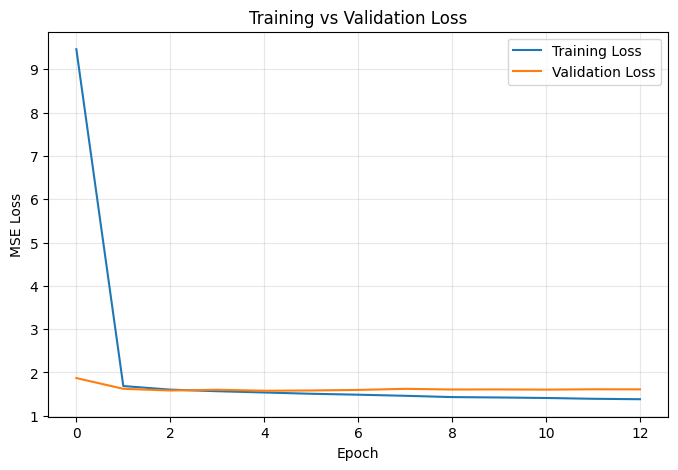

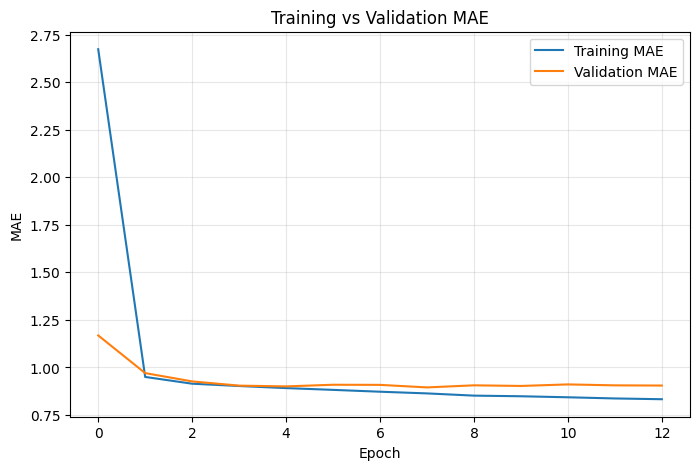

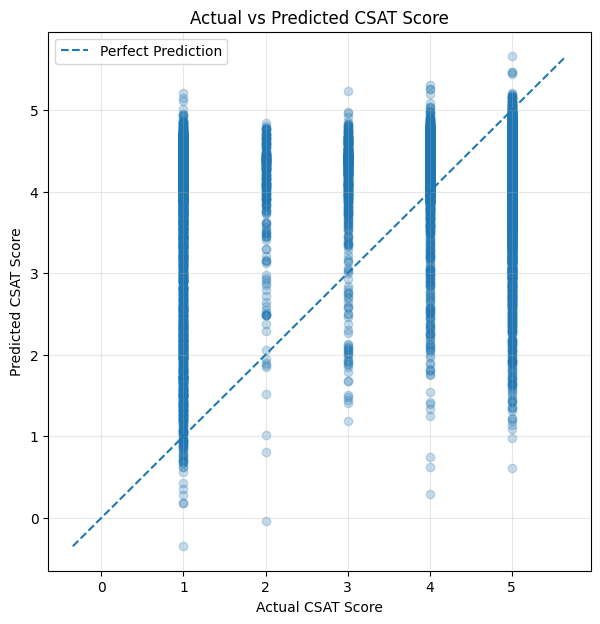

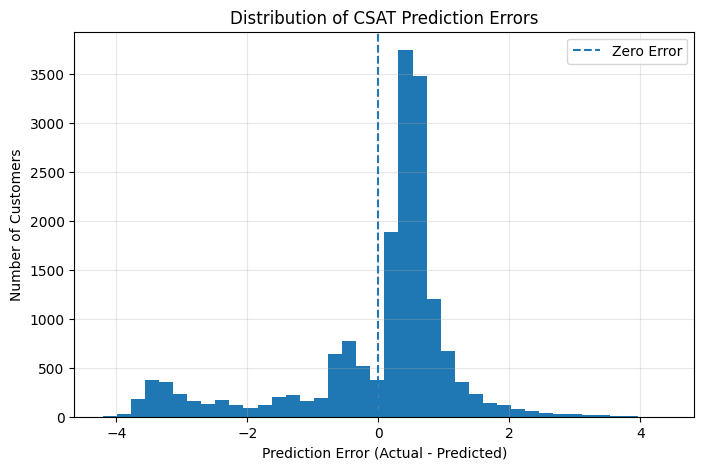


FINAL MODEL SUMMARY
Test records evaluated : 17,182
MAE                    : 0.8997
RMSE                   : 1.2513
R²                     : 0.1764

✅ Model evaluation completed successfully.


In [25]:
# ============================================================
# CELL 6: MODEL EVALUATION & PERFORMANCE VISUALIZATION
# ============================================================
#
# PURPOSE:
# Evaluate how accurately the Deep Learning model predicts
# customer satisfaction (CSAT) scores.
#
# The model predicts a continuous numerical value between
# approximately 1 and 5.
#
# Main evaluation metrics:
#
#   MAE  -> Average absolute prediction error
#   RMSE -> Penalizes large prediction errors more strongly
#   R²   -> How much variation in CSAT is explained by the model
#
# We also visualize:
#
#   1. Training vs Validation Loss
#   2. Training vs Validation MAE
#   3. Actual vs Predicted CSAT
#   4. Prediction Error Distribution
#
# ============================================================


# ------------------------------------------------------------
# 1. IMPORT REQUIRED LIBRARIES
# ------------------------------------------------------------

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# 2. GENERATE PREDICTIONS
# ============================================================
#
# X_test contains customer records that were not used for
# updating the neural-network weights.
#
# The model produces one predicted CSAT value for each
# test record.
#
# .ravel() converts the prediction from:
#
#     (number_of_records, 1)
#
# into:
#
#     (number_of_records,)
#
# ============================================================

y_pred = model.predict(X_test, verbose=0).ravel()


# ============================================================
# 3. CHECK FOR INVALID PREDICTIONS
# ============================================================
#
# Neural networks normally produce valid numerical predictions.
# However, we check for NaN or infinite values before calculating
# evaluation metrics.
#
# This prevents metric calculation errors.
#
# ============================================================

valid_indices = (
    np.isfinite(y_pred) &
    np.isfinite(np.asarray(y_test))
)

y_pred_valid = y_pred[valid_indices]
y_test_valid = np.asarray(y_test)[valid_indices]


print("=" * 60)
print("PREDICTION VALIDATION")
print("=" * 60)

print(f"Total test records       : {len(y_test):,}")
print(f"Valid predictions        : {len(y_pred_valid):,}")
print(f"Invalid predictions      : {np.sum(~valid_indices):,}")


# ============================================================
# 4. CALCULATE EVALUATION METRICS
# ============================================================
#
# MAE:
# Average absolute difference between actual and predicted CSAT.
#
# Example:
#
# Actual     = 4
# Predicted  = 3.5
# Error      = 0.5
#
# MAE is easy to interpret because it is expressed in CSAT points.
#
#
# RMSE:
# Similar to MAE, but large errors receive greater penalty.
#
#
# R²:
# Measures how well the model explains variation in the target.
#
# R² = 1.0 -> perfect prediction
# R² = 0.0 -> no better than predicting the mean
# R² < 0   -> worse than the mean baseline
#
# ============================================================

mae = mean_absolute_error(
    y_test_valid,
    y_pred_valid
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_valid,
        y_pred_valid
    )
)

r2 = r2_score(
    y_test_valid,
    y_pred_valid
)


# ============================================================
# 5. DISPLAY FINAL MODEL PERFORMANCE
# ============================================================

print("\n" + "=" * 60)
print("        CSAT PREDICTION MODEL EVALUATION")
print("=" * 60)

print(f"Mean Absolute Error (MAE) : {mae:.4f}")
print(f"Root Mean Squared Error   : {rmse:.4f}")
print(f"R² Score                  : {r2:.4f}")

print("=" * 60)


# ============================================================
# 6. TRAINING & VALIDATION LOSS CURVE
# ============================================================
#
# This graph shows whether the neural network learned
# effectively during training.
#
# Training loss:
#   Error calculated on training data.
#
# Validation loss:
#   Error calculated on validation data after each epoch.
#
# Ideally:
#
#   Both decrease initially.
#
# If training loss continues decreasing while validation loss
# starts increasing, this may indicate overfitting.
#
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ============================================================
# 7. TRAINING & VALIDATION MAE CURVE
# ============================================================
#
# MAE shows the average prediction error in CSAT points.
#
# Lower MAE = better performance.
#
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['mae'],
    label='Training MAE'
)

plt.plot(
    history.history['val_mae'],
    label='Validation MAE'
)

plt.title('Training vs Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ============================================================
# 8. ACTUAL VS PREDICTED CSAT
# ============================================================
#
# This graph compares:
#
#   X-axis -> Actual CSAT Score
#   Y-axis -> Predicted CSAT Score
#
# If predictions are accurate, points should be close to the
# diagonal line:
#
#     Predicted = Actual
#
# ============================================================

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test_valid,
    y_pred_valid,
    alpha=0.25
)

# Perfect prediction reference line.
min_score = min(
    y_test_valid.min(),
    y_pred_valid.min()
)

max_score = max(
    y_test_valid.max(),
    y_pred_valid.max()
)

plt.plot(
    [min_score, max_score],
    [min_score, max_score],
    linestyle='--',
    label='Perfect Prediction'
)

plt.title('Actual vs Predicted CSAT Score')
plt.xlabel('Actual CSAT Score')
plt.ylabel('Predicted CSAT Score')
plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ============================================================
# 9. PREDICTION ERROR DISTRIBUTION
# ============================================================
#
# Prediction error is calculated as:
#
#     Actual CSAT - Predicted CSAT
#
# An error close to 0 means the prediction is accurate.
#
# A distribution centered around 0 generally indicates that
# the model is not consistently overpredicting or underpredicting.
#
# ============================================================

errors = y_test_valid - y_pred_valid

plt.figure(figsize=(8, 5))

plt.hist(
    errors,
    bins=40
)

plt.axvline(
    0,
    linestyle='--',
    label='Zero Error'
)

plt.title('Distribution of CSAT Prediction Errors')
plt.xlabel('Prediction Error (Actual - Predicted)')
plt.ylabel('Number of Customers')
plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ============================================================
# 10. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("FINAL MODEL SUMMARY")
print("=" * 60)

print(f"Test records evaluated : {len(y_test_valid):,}")
print(f"MAE                    : {mae:.4f}")
print(f"RMSE                   : {rmse:.4f}")
print(f"R²                     : {r2:.4f}")

print("\n✅ Model evaluation completed successfully.")

In [ ]:
# # Cell 7: Live Interactive Web UI inside Colab
# !pip install -q gradio

# import gradio as gr
# import pandas as pd # Import pandas for DataFrame creation
# import numpy as np  # Import numpy for np.clip
# import nltk
# from nltk.sentiment.vader import SentimentIntensityAnalyzer
# nltk.download('vader_lexicon', quiet=True) # Ensure vader_lexicon is downloaded if not already

# # Initialize SIA for sentiment analysis (once)
# sia = SentimentIntensityAnalyzer()

# def predict_csat(channel_name, category, item_price, handling_time, customer_remark):
#     # Derive features from customer_remark consistent with Cell 3 and Cell 4's numerical_cols
#     sentiment_scores = sia.polarity_scores(customer_remark)

#     rem_len = len(customer_remark)
#     sentiment_compound = sentiment_scores['compound']
#     sentiment_neg = sentiment_scores['neg']
#     sentiment_pos = sentiment_scores['pos']

#     # Construct input dataframe with exact column names as used during training
#     # IMPORTANT: The order of columns here must match the order in num_present + cat_present from Cell 4
#     sample = pd.DataFrame([{
#         'Item price': float(item_price),
#         'Connected handling time': float(handling_time),
#         'response_time_min': 15.0, # Default value
#         'order_to_issue_delay_hrs': 24.0, # Default value
#         'issue_hour': 12, # Default value
#         'issue_dayofweek': 1, # Default value
#         'is_weekend': 0, # Default value
#         'remark_length': rem_len,
#         'sentiment_compound': sentiment_compound,
#         'sentiment_neg': sentiment_neg,
#         'sentiment_pos': sentiment_pos,
#         'channel_name': channel_name,
#         'category': category,
#         'Sub-category': 'Unknown',  # Placeholder for features not in Gradio input
#         'Customer city': 'Unknown',  # Corrected name, placeholder
#         'Product_category': 'Unknown', # Placeholder
#         'Tenure Bucket': 'On Job Training', # Placeholder
#         'Agent Shift': 'Morning' # Placeholder
#     }])

#     # Preprocess & Predict
#     # Ensure num_present and cat_present are globally available from Cell 4
#     all_features_for_preprocessor = num_present + cat_present
#     transformed = preprocessor.transform(sample[all_features_for_preprocessor])
#     pred = model.predict(transformed, verbose=0)[0][0]

#     # Clip output to 1.0 - 5.0 range
#     score = round(float(np.clip(pred, 1.0, 5.0)), 2)
#     return f"Predicted CSAT Score: {score} / 5.0"

# # Launch Gradio interface
# iface = gr.Interface(
#     fn=predict_csat,
#     inputs=[
#         gr.Dropdown(["Outcall", "Inbound", "In-app Chat", "Email"], label="Channel Name", value="Outcall"),
#         gr.Dropdown(["Product Queries", "Returns", "Order Tracking", "Refunds"], label="Category", value="Product Queries"),
#         gr.Number(label="Item Price ($)", value=150.0),
#         gr.Number(label="Connected Handling Time (secs)", value=120.0),
#         gr.Textbox(label="Customer Remark", value="The agent was very helpful and resolved my issue quickly.")
#     ],
#     outputs="text",
#     title="Shopzilla CSAT Deep Learning Engine",
#     description="Live CSAT Score Prediction powered by Residual Attention Artificial Neural Network."
# )

# iface.launch(share=True, debug=False)

In [30]:
# ============================================================
# CELL 7: LIVE INTERACTIVE WEB UI INSIDE GOOGLE COLAB
# ============================================================
#
# PURPOSE:
# Create a Gradio web interface for live CSAT prediction.
#
# IMPORTANT:
# The feature names below EXACTLY match the columns created
# in Cells 3 and 4.
#
# ============================================================


# ------------------------------------------------------------
# 1. INSTALL / UPDATE GRADIO
# ------------------------------------------------------------

!pip install -q -U gradio


# ------------------------------------------------------------
# 2. IMPORT LIBRARIES
# ------------------------------------------------------------

import gradio as gr
import pandas as pd
import numpy as np

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download VADER lexicon
nltk.download('vader_lexicon', quiet=True)

# Initialize sentiment analyzer
sia = SentimentIntensityAnalyzer()


# ============================================================
# 3. VERIFY REQUIRED VARIABLES FROM PREVIOUS CELLS
# ============================================================

required_variables = [
    'model',
    'preprocessor',
    'num_present',
    'cat_present'
]

for variable in required_variables:
    if variable not in globals():
        raise RuntimeError(
            f"❌ Required variable '{variable}' is missing. "
            f"Please run Cells 3, 4 and 5 before Cell 7."
        )


# ============================================================
# 4. DISPLAY FEATURES USED BY THE MODEL
# ============================================================

print("=" * 60)
print("DEEP CSAT LIVE PREDICTION SYSTEM")
print("=" * 60)

print("\nNumerical features:")
print(num_present)

print("\nCategorical features:")
print(cat_present)

print("\nTotal input features:", len(num_present) + len(cat_present))


# ============================================================
# 5. GET DROPDOWN VALUES FROM THE ACTUAL DATASET
# ============================================================
#
# Instead of manually typing category values, use the values
# that actually exist in df.
#
# This prevents the UI from using invalid categories.
# ============================================================

def get_dropdown_values(column, fallback="Unknown"):

    if column in df.columns:

        values = (
            df[column]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )

        values = sorted(values)

        if len(values) > 0:
            return values

    return [fallback]


channel_values = get_dropdown_values(
    'channel_name'
)

category_values = get_dropdown_values(
    'category'
)

subcategory_values = get_dropdown_values(
    'Sub-category'
)

city_values = get_dropdown_values(
    'Customer_City'
)

product_category_values = get_dropdown_values(
    'Product_category'
)

tenure_values = get_dropdown_values(
    'Tenure Bucket'
)

shift_values = get_dropdown_values(
    'Agent Shift'
)


# ============================================================
# 6. LIVE CSAT PREDICTION FUNCTION
# ============================================================

def predict_csat(
    channel_name,
    category,
    subcategory,
    customer_city,
    product_category,
    item_price,
    tenure_bucket,
    agent_shift,
    handling_time,
    customer_remark
):

    # --------------------------------------------------------
    # A. CLEAN USER INPUT
    # --------------------------------------------------------

    customer_remark = str(customer_remark)

    item_price = float(item_price)
    handling_time = float(handling_time)


    # --------------------------------------------------------
    # B. SENTIMENT FEATURES
    # --------------------------------------------------------

    sentiment_scores = sia.polarity_scores(
        customer_remark
    )

    sentiment_compound = sentiment_scores['compound']
    sentiment_neg = sentiment_scores['neg']
    sentiment_pos = sentiment_scores['pos']

    remark_length = len(customer_remark)


    # --------------------------------------------------------
    # C. ENGINEERED TIME FEATURES
    # --------------------------------------------------------
    #
    # These values are defaults because the live UI does not
    # ask the user for issue/order timestamps.
    #
    # They MUST still be supplied because the trained model
    # expects these features.
    #
    # --------------------------------------------------------

    response_time_min = handling_time / 60.0

    order_to_issue_delay_hrs = 24.0

    issue_hour = 12

    issue_dayofweek = 1

    is_weekend = 0


    # ========================================================
    # D. CREATE INPUT DATAFRAME
    # ========================================================
    #
    # IMPORTANT:
    # These names EXACTLY match df.columns.
    #
    # ========================================================

    sample = pd.DataFrame([{

        # Numerical features
        'Item_price': item_price,

        'response_time_min': response_time_min,

        'order_to_issue_delay_hrs':
            order_to_issue_delay_hrs,

        'issue_hour':
            issue_hour,

        'issue_dayofweek':
            issue_dayofweek,

        'is_weekend':
            is_weekend,

        'remark_length':
            remark_length,

        'sentiment_compound':
            sentiment_compound,

        'sentiment_neg':
            sentiment_neg,

        'sentiment_pos':
            sentiment_pos,


        # Categorical features
        'channel_name':
            channel_name,

        'category':
            category,

        'Sub-category':
            subcategory,

        'Customer_City':
            customer_city,

        'Product_category':
            product_category,

        'Tenure Bucket':
            tenure_bucket,

        'Agent Shift':
            agent_shift
    }])


    # ========================================================
    # E. ARRANGE COLUMNS EXACTLY LIKE CELL 4
    # ========================================================

    feature_columns = num_present + cat_present

    sample = sample[feature_columns]


    # ========================================================
    # F. APPLY SAME PREPROCESSING AS TRAINING
    # ========================================================
    #
    # DO NOT create a new scaler or encoder here.
    #
    # We use the SAME preprocessor fitted in Cell 4.
    #
    # ========================================================

    transformed = preprocessor.transform(sample)


    # ========================================================
    # G. MODEL PREDICTION
    # ========================================================

    prediction = model.predict(
        transformed,
        verbose=0
    )[0][0]


    # ========================================================
    # H. LIMIT CSAT TO VALID 1-5 RANGE
    # ========================================================

    score = float(
        np.clip(
            prediction,
            1.0,
            5.0
        )
    )

    score = round(score, 2)


    # ========================================================
    # I. RETURN RESULT
    # ========================================================

    return (
        f"⭐ Predicted CSAT Score: {score} / 5.0"
    )


# ============================================================
# 7. BUILD GRADIO WEB APPLICATION
# ============================================================
#
# We use gr.Blocks instead of the older gr.Interface API.
#
# This avoids the 'allow_flagging' compatibility error shown
# in your screenshot.
#
# ============================================================

with gr.Blocks(
    title="DeepCSAT Prediction Engine"
) as demo:

    gr.Markdown(
        """
        # ⭐ DeepCSAT Prediction Engine

        ### Customer Satisfaction Score Prediction

        Enter customer and interaction information below.
        The trained Deep Learning model will predict the
        expected CSAT score from **1 to 5**.
        """
    )


    # --------------------------------------------------------
    # INPUT SECTION
    # --------------------------------------------------------

    with gr.Row():

        with gr.Column():

            channel_input = gr.Dropdown(
                choices=channel_values,
                label="Channel Name",
                value=channel_values[0]
            )

            category_input = gr.Dropdown(
                choices=category_values,
                label="Category",
                value=category_values[0]
            )

            subcategory_input = gr.Dropdown(
                choices=subcategory_values,
                label="Sub-category",
                value=subcategory_values[0]
            )

            city_input = gr.Dropdown(
                choices=city_values,
                label="Customer City",
                value=city_values[0]
            )


        with gr.Column():

            product_category_input = gr.Dropdown(
                choices=product_category_values,
                label="Product Category",
                value=product_category_values[0]
            )

            tenure_input = gr.Dropdown(
                choices=tenure_values,
                label="Tenure Bucket",
                value=tenure_values[0]
            )

            shift_input = gr.Dropdown(
                choices=shift_values,
                label="Agent Shift",
                value=shift_values[0]
            )

            item_price_input = gr.Number(
                label="Item Price",
                value=150.0
            )


    # --------------------------------------------------------
    # CUSTOMER INTERACTION SECTION
    # --------------------------------------------------------

    handling_time_input = gr.Number(
        label="Handling Time (seconds)",
        value=120.0
    )

    remark_input = gr.Textbox(
        label="Customer Remark",
        placeholder="Enter customer's feedback...",
        value=(
            "The agent was very helpful "
            "and resolved my issue quickly."
        ),
        lines=4
    )


    # --------------------------------------------------------
    # PREDICTION BUTTON
    # --------------------------------------------------------

    predict_button = gr.Button(
        "🔮 Predict CSAT Score"
    )


    # --------------------------------------------------------
    # OUTPUT
    # --------------------------------------------------------

    output = gr.Textbox(
        label="Prediction Result",
        interactive=False
    )


    # --------------------------------------------------------
    # CONNECT BUTTON TO FUNCTION
    # --------------------------------------------------------

    predict_button.click(
        fn=predict_csat,

        inputs=[
            channel_input,
            category_input,
            subcategory_input,
            city_input,
            product_category_input,
            item_price_input,
            tenure_input,
            shift_input,
            handling_time_input,
            remark_input
        ],

        outputs=output
    )

# ============================================================
# 8. LAUNCH WEB APPLICATION
# ============================================================

print("\n" + "=" * 60)
print("🚀 LAUNCHING DEEP CSAT WEB APPLICATION")
print("=" * 60)

# Launch Gradio without blocking the Colab cell.
# The web app will continue running while this cell finishes.
demo.launch(
    share=True,
    debug=False,
    prevent_thread_lock=True
)

print("\n" + "=" * 60)
print("✅ WEB APPLICATION LAUNCHED")
print("✅ COLAB CELL FINISHED")
print("✅ You can use the Gradio link above.")
print("=" * 60)

DEEP CSAT LIVE PREDICTION SYSTEM

Numerical features:
['Item_price', 'response_time_min', 'order_to_issue_delay_hrs', 'issue_hour', 'issue_dayofweek', 'is_weekend', 'remark_length', 'sentiment_compound', 'sentiment_neg', 'sentiment_pos']

Categorical features:
['channel_name', 'category', 'Sub-category', 'Customer_City', 'Product_category', 'Tenure Bucket', 'Agent Shift']

Total input features: 17

🚀 LAUNCHING DEEP CSAT WEB APPLICATION
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f5e47d6e42f26c4870.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



✅ WEB APPLICATION LAUNCHED
✅ COLAB CELL FINISHED
✅ You can use the Gradio link above.


In [32]:
# ============================================================
# SAVE DEEPCSAT MODEL FOR DEPLOYMENT
# ============================================================

import os
import joblib
import tensorflow as tf
import sklearn

# Save trained TensorFlow/Keras model
model.save("csat_model.keras")

# Save the preprocessing pipeline
joblib.dump(preprocessor, "preprocessor.pkl")

print("=" * 60)
print("MODEL DEPLOYMENT FILES CREATED")
print("=" * 60)

print("✅ csat_model.keras")
print("✅ preprocessor.pkl")

print("\nLibrary versions:")
print("TensorFlow :", tf.__version__)
print("Scikit-learn:", sklearn.__version__)

print("\nFiles:")
print(os.listdir("."))

MODEL DEPLOYMENT FILES CREATED
✅ csat_model.keras
✅ preprocessor.pkl

Library versions:
TensorFlow : 2.20.0
Scikit-learn: 1.6.1

Files:
['.config', '.gradio', 'csat_model.keras', 'preprocessor.pkl', 'eCommerce_Customer_support_data.csv', 'sample_data']


In [33]:
# ============================================================
# CREATE REQUIREMENTS.TXT
# ============================================================

import tensorflow as tf
import sklearn
import gradio

requirements = f"""gradio
tensorflow=={tf.__version__}
scikit-learn=={sklearn.__version__}
pandas
numpy
joblib
nltk
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print(requirements)

gradio
tensorflow==2.20.0
scikit-learn==1.6.1
pandas
numpy
joblib
nltk



In [34]:
model
preprocessor
num_present
cat_present

['channel_name',
 'category',
 'Sub-category',
 'Customer_City',
 'Product_category',
 'Tenure Bucket',
 'Agent Shift']

In [35]:
# ============================================================
# DEEPCSAT - CUSTOMER SATISFACTION PREDICTION APPLICATION
# ============================================================

import gradio as gr
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf
import nltk

from nltk.sentiment.vader import SentimentIntensityAnalyzer


# ============================================================
# 1. DOWNLOAD VADER SENTIMENT DICTIONARY
# ============================================================

nltk.download("vader_lexicon", quiet=True)

sia = SentimentIntensityAnalyzer()


# ============================================================
# 2. LOAD TRAINED MODEL AND PREPROCESSOR
# ============================================================

MODEL_PATH = "csat_model.keras"
PREPROCESSOR_PATH = "preprocessor.pkl"

model = tf.keras.models.load_model(MODEL_PATH)

preprocessor = joblib.load(PREPROCESSOR_PATH)


# ============================================================
# 3. FEATURES USED DURING TRAINING
# ============================================================

numerical_features = [
    "Item_price",
    "response_time_min",
    "order_to_issue_delay_hrs",
    "issue_hour",
    "issue_dayofweek",
    "is_weekend",
    "remark_length",
    "sentiment_compound",
    "sentiment_neg",
    "sentiment_pos"
]

categorical_features = [
    "channel_name",
    "category",
    "Sub-category",
    "Customer_City",
    "Product_category",
    "Tenure Bucket",
    "Agent Shift"
]

feature_columns = numerical_features + categorical_features


# ============================================================
# 4. CSAT PREDICTION FUNCTION
# ============================================================

def predict_csat(
    channel_name,
    category,
    sub_category,
    customer_city,
    product_category,
    tenure_bucket,
    agent_shift,
    item_price,
    handling_time,
    customer_remark
):

    # --------------------------------------------------------
    # SENTIMENT ANALYSIS
    # --------------------------------------------------------

    customer_remark = str(customer_remark)

    sentiment_scores = sia.polarity_scores(customer_remark)

    sentiment_compound = sentiment_scores["compound"]
    sentiment_neg = sentiment_scores["neg"]
    sentiment_pos = sentiment_scores["pos"]

    remark_length = len(customer_remark)


    # --------------------------------------------------------
    # DEFAULT OPERATIONAL FEATURES
    # --------------------------------------------------------

    # These are default values because the deployed UI does
    # not ask the user for timestamps.
    response_time_min = 15.0
    order_to_issue_delay_hrs = 24.0
    issue_hour = 12
    issue_dayofweek = 1
    is_weekend = 0


    # --------------------------------------------------------
    # CREATE INPUT DATAFRAME
    # --------------------------------------------------------

    sample = pd.DataFrame([{

        # Numerical features
        "Item_price": float(item_price),

        "response_time_min": response_time_min,

        "order_to_issue_delay_hrs":
            order_to_issue_delay_hrs,

        "issue_hour": issue_hour,

        "issue_dayofweek": issue_dayofweek,

        "is_weekend": is_weekend,

        "remark_length": remark_length,

        "sentiment_compound":
            sentiment_compound,

        "sentiment_neg":
            sentiment_neg,

        "sentiment_pos":
            sentiment_pos,

        # Categorical features
        "channel_name": channel_name,

        "category": category,

        "Sub-category": sub_category,

        "Customer_City": customer_city,

        "Product_category": product_category,

        "Tenure Bucket": tenure_bucket,

        "Agent Shift": agent_shift
    }])


    # --------------------------------------------------------
    # PREPROCESS
    # --------------------------------------------------------

    transformed = preprocessor.transform(
        sample[feature_columns]
    )


    # --------------------------------------------------------
    # PREDICTION
    # --------------------------------------------------------

    prediction = model.predict(
        transformed,
        verbose=0
    )[0][0]


    # Keep CSAT within valid 1-5 range
    score = float(
        np.clip(prediction, 1.0, 5.0)
    )

    score = round(score, 2)


    # --------------------------------------------------------
    # RESULT
    # --------------------------------------------------------

    return f"⭐ Predicted CSAT Score: {score} / 5.0"


# ============================================================
# 5. GRADIO WEB INTERFACE
# ============================================================

demo = gr.Interface(

    fn=predict_csat,

    inputs=[

        gr.Dropdown(
            choices=[
                "Outcall",
                "Inbound",
                "In-app Chat",
                "Email"
            ],
            label="Channel Name",
            value="Email"
        ),

        gr.Dropdown(
            choices=[
                "App/website",
                "Product Queries",
                "Returns",
                "Order Tracking",
                "Refunds"
            ],
            label="Category",
            value="App/website"
        ),

        gr.Textbox(
            label="Sub-category",
            value="Account updation"
        ),

        gr.Textbox(
            label="Customer City",
            value="ABOHAR"
        ),

        gr.Textbox(
            label="Product Category",
            value="Affiliates"
        ),

        gr.Dropdown(
            choices=[
                "0-30",
                "31-60",
                "61-90",
                "90+",
                "On Job Training"
            ],
            label="Tenure Bucket",
            value="0-30"
        ),

        gr.Dropdown(
            choices=[
                "Morning",
                "Afternoon",
                "Evening",
                "Night"
            ],
            label="Agent Shift",
            value="Afternoon"
        ),

        gr.Number(
            label="Item Price",
            value=150
        ),

        gr.Number(
            label="Handling Time (seconds)",
            value=120
        ),

        gr.Textbox(
            label="Customer Remark",
            value=(
                "The agent was very helpful "
                "and resolved my issue quickly."
            ),
            lines=4
        )
    ],

    outputs=gr.Textbox(
        label="Prediction Result"
    ),

    title="🔮 DeepCSAT Prediction Engine",

    description=(
        "Customer Satisfaction Score Prediction "
        "using a Deep Learning Residual Attention "
        "Artificial Neural Network."
    )
)


# ============================================================
# 6. LAUNCH
# ============================================================

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a329da62bd294a3726.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [36]:
# ============================================================
# TEST DEPLOYMENT FILES
# ============================================================

import tensorflow as tf
import joblib

test_model = tf.keras.models.load_model(
    "csat_model.keras"
)

test_preprocessor = joblib.load(
    "preprocessor.pkl"
)

print("✅ Model loaded successfully")
print("✅ Preprocessor loaded successfully")

print("\nModel input shape:")
print(test_model.input_shape)

print("\nDeployment files are ready.")

✅ Model loaded successfully
✅ Preprocessor loaded successfully

Model input shape:
(None, 1724)

Deployment files are ready.


In [37]:
%%writefile app.py

# ============================================================
# DEEPCSAT - CUSTOMER SATISFACTION PREDICTION APPLICATION
# ============================================================

import gradio as gr
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf
import nltk

from nltk.sentiment.vader import SentimentIntensityAnalyzer


# ============================================================
# 1. DOWNLOAD VADER SENTIMENT DICTIONARY
# ============================================================

nltk.download("vader_lexicon", quiet=True)

sia = SentimentIntensityAnalyzer()


# ============================================================
# 2. LOAD TRAINED MODEL AND PREPROCESSOR
# ============================================================

MODEL_PATH = "csat_model.keras"
PREPROCESSOR_PATH = "preprocessor.pkl"

model = tf.keras.models.load_model(MODEL_PATH)

preprocessor = joblib.load(PREPROCESSOR_PATH)


# ============================================================
# 3. FEATURES USED DURING TRAINING
# ============================================================

numerical_features = [
    "Item_price",
    "response_time_min",
    "order_to_issue_delay_hrs",
    "issue_hour",
    "issue_dayofweek",
    "is_weekend",
    "remark_length",
    "sentiment_compound",
    "sentiment_neg",
    "sentiment_pos"
]

categorical_features = [
    "channel_name",
    "category",
    "Sub-category",
    "Customer_City",
    "Product_category",
    "Tenure Bucket",
    "Agent Shift"
]

feature_columns = numerical_features + categorical_features


# ============================================================
# 4. CSAT PREDICTION FUNCTION
# ============================================================

def predict_csat(
    channel_name,
    category,
    sub_category,
    customer_city,
    product_category,
    tenure_bucket,
    agent_shift,
    item_price,
    handling_time,
    customer_remark
):

    # --------------------------------------------------------
    # SENTIMENT ANALYSIS
    # --------------------------------------------------------

    customer_remark = str(customer_remark)

    sentiment_scores = sia.polarity_scores(customer_remark)

    sentiment_compound = sentiment_scores["compound"]
    sentiment_neg = sentiment_scores["neg"]
    sentiment_pos = sentiment_scores["pos"]

    remark_length = len(customer_remark)


    # --------------------------------------------------------
    # DEFAULT OPERATIONAL FEATURES
    # --------------------------------------------------------

    # These are default values because the deployed UI does
    # not ask the user for timestamps.
    response_time_min = 15.0
    order_to_issue_delay_hrs = 24.0
    issue_hour = 12
    issue_dayofweek = 1
    is_weekend = 0


    # --------------------------------------------------------
    # CREATE INPUT DATAFRAME
    # --------------------------------------------------------

    sample = pd.DataFrame([{

        # Numerical features
        "Item_price": float(item_price),

        "response_time_min": response_time_min,

        "order_to_issue_delay_hrs":
            order_to_issue_delay_hrs,

        "issue_hour": issue_hour,

        "issue_dayofweek": issue_dayofweek,

        "is_weekend": is_weekend,

        "remark_length": remark_length,

        "sentiment_compound":
            sentiment_compound,

        "sentiment_neg":
            sentiment_neg,

        "sentiment_pos":
            sentiment_pos,

        # Categorical features
        "channel_name": channel_name,

        "category": category,

        "Sub-category": sub_category,

        "Customer_City": customer_city,

        "Product_category": product_category,

        "Tenure Bucket": tenure_bucket,

        "Agent Shift": agent_shift
    }])


    # --------------------------------------------------------
    # PREPROCESS
    # --------------------------------------------------------

    transformed = preprocessor.transform(
        sample[feature_columns]
    )


    # --------------------------------------------------------
    # PREDICTION
    # --------------------------------------------------------

    prediction = model.predict(
        transformed,
        verbose=0
    )[0][0]


    # Keep CSAT within valid 1-5 range
    score = float(
        np.clip(prediction, 1.0, 5.0)
    )

    score = round(score, 2)


    # --------------------------------------------------------
    # RESULT
    # --------------------------------------------------------

    return f"⭐ Predicted CSAT Score: {score} / 5.0"


# ============================================================
# 5. GRADIO WEB INTERFACE
# ============================================================

demo = gr.Interface(

    fn=predict_csat,

    inputs=[

        gr.Dropdown(
            choices=[
                "Outcall",
                "Inbound",
                "In-app Chat",
                "Email"
            ],
            label="Channel Name",
            value="Email"
        ),

        gr.Dropdown(
            choices=[
                "App/website",
                "Product Queries",
                "Returns",
                "Order Tracking",
                "Refunds"
            ],
            label="Category",
            value="App/website"
        ),

        gr.Textbox(
            label="Sub-category",
            value="Account updation"
        ),

        gr.Textbox(
            label="Customer City",
            value="ABOHAR"
        ),

        gr.Textbox(
            label="Product Category",
            value="Affiliates"
        ),

        gr.Dropdown(
            choices=[
                "0-30",
                "31-60",
                "61-90",
                "90+",
                "On Job Training"
            ],
            label="Tenure Bucket",
            value="0-30"
        ),

        gr.Dropdown(
            choices=[
                "Morning",
                "Afternoon",
                "Evening",
                "Night"
            ],
            label="Agent Shift",
            value="Afternoon"
        ),

        gr.Number(
            label="Item Price",
            value=150
        ),

        gr.Number(
            label="Handling Time (seconds)",
            value=120
        ),

        gr.Textbox(
            label="Customer Remark",
            value=(
                "The agent was very helpful "
                "and resolved my issue quickly."
            ),
            lines=4
        )
    ],

    outputs=gr.Textbox(
        label="Prediction Result"
    ),

    title="🔮 DeepCSAT Prediction Engine",

    description=(
        "Customer Satisfaction Score Prediction "
        "using a Deep Learning Residual Attention "
        "Artificial Neural Network."
    )
)


# ============================================================
# 6. LAUNCH
# ============================================================

demo.launch()

Writing app.py


In [38]:
# ============================================================
# SAVE TRAINED MODEL FOR HUGGING FACE DEPLOYMENT
# ============================================================

import joblib
import os

# Save the trained neural network
model.save("model.keras")

# Save the preprocessing pipeline
joblib.dump(preprocessor, "preprocessor.pkl")

print("==============================================")
print("MODEL DEPLOYMENT FILES SAVED")
print("==============================================")
print("model.keras       :", os.path.getsize("model.keras"), "bytes")
print("preprocessor.pkl  :", os.path.getsize("preprocessor.pkl"), "bytes")
print("==============================================")
print("Ready for Hugging Face deployment.")

MODEL DEPLOYMENT FILES SAVED
model.keras       : 38710957 bytes
preprocessor.pkl  : 24177 bytes
Ready for Hugging Face deployment.
